In [1]:
import qft_analysis_pqc as qft
import load_circuits as lc

import pprint
from qiskit.qasm3 import loads
import pandas as pd
import csv


These circuits are the circuits that use Fire Opal. Circuit Ids are from 0 to 579 for each qft_method (580 circuits for each method)

In [ ]:
circuit_df = qft.process_qft_experiments(".../parity_qc_data/circuit_data_fo.json.gz")

In [3]:
print(circuit_df)

                                     transpiled_circuit        qft_method  \
0     OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2]...  TwineQFTHeavyHex   
1     OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2]...  TwineQFTHeavyHex   
2     OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2]...  TwineQFTHeavyHex   
3     OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2]...  TwineQFTHeavyHex   
4     OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2]...  TwineQFTHeavyHex   
...                                                 ...               ...   
1735  OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[58...         FowlerQFT   
1736  OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[58...         FowlerQFT   
1737  OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[58...         FowlerQFT   
1738  OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[58...         FowlerQFT   
1739  OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[58...         FowlerQFT   

         backend  number_of_qubits   basis_state_index  \
0     ibm_boston 

In [4]:
print(circuit_df['qft_method'].value_counts())

qft_method
TwineQFTHeavyHex    580
TwineQFTLinear      580
FowlerQFT           580
Name: count, dtype: int64


In [5]:
# Example: Grabs the very first circuit that belongs to 'FowlerQFT'
#each id number will go from 0 to 579 for each qft method 
circuit = lc.get_circuit(circuit_df, id_number=0, qft_method='TwineQFTHeavyHex')
print(circuit)

OPENQASM 3.0;
include "stdgates.inc";
bit[2] c;
qubit[2] q;
h q[0];
rz(0) q[0];
h q[1];
rz(0) q[1];
rz(pi/2) q[0];
rz(3*pi/4) q[1];
rx(pi/2) q[0];
cx q[1], q[0];
cx q[0], q[1];
rz(-pi/4) q[0];
cx q[1], q[0];
rx(pi/2) q[0];
rz(pi/2) q[0];
rz(3*pi/4) q[1];
c[0] = measure q[0];
c[1] = measure q[1];



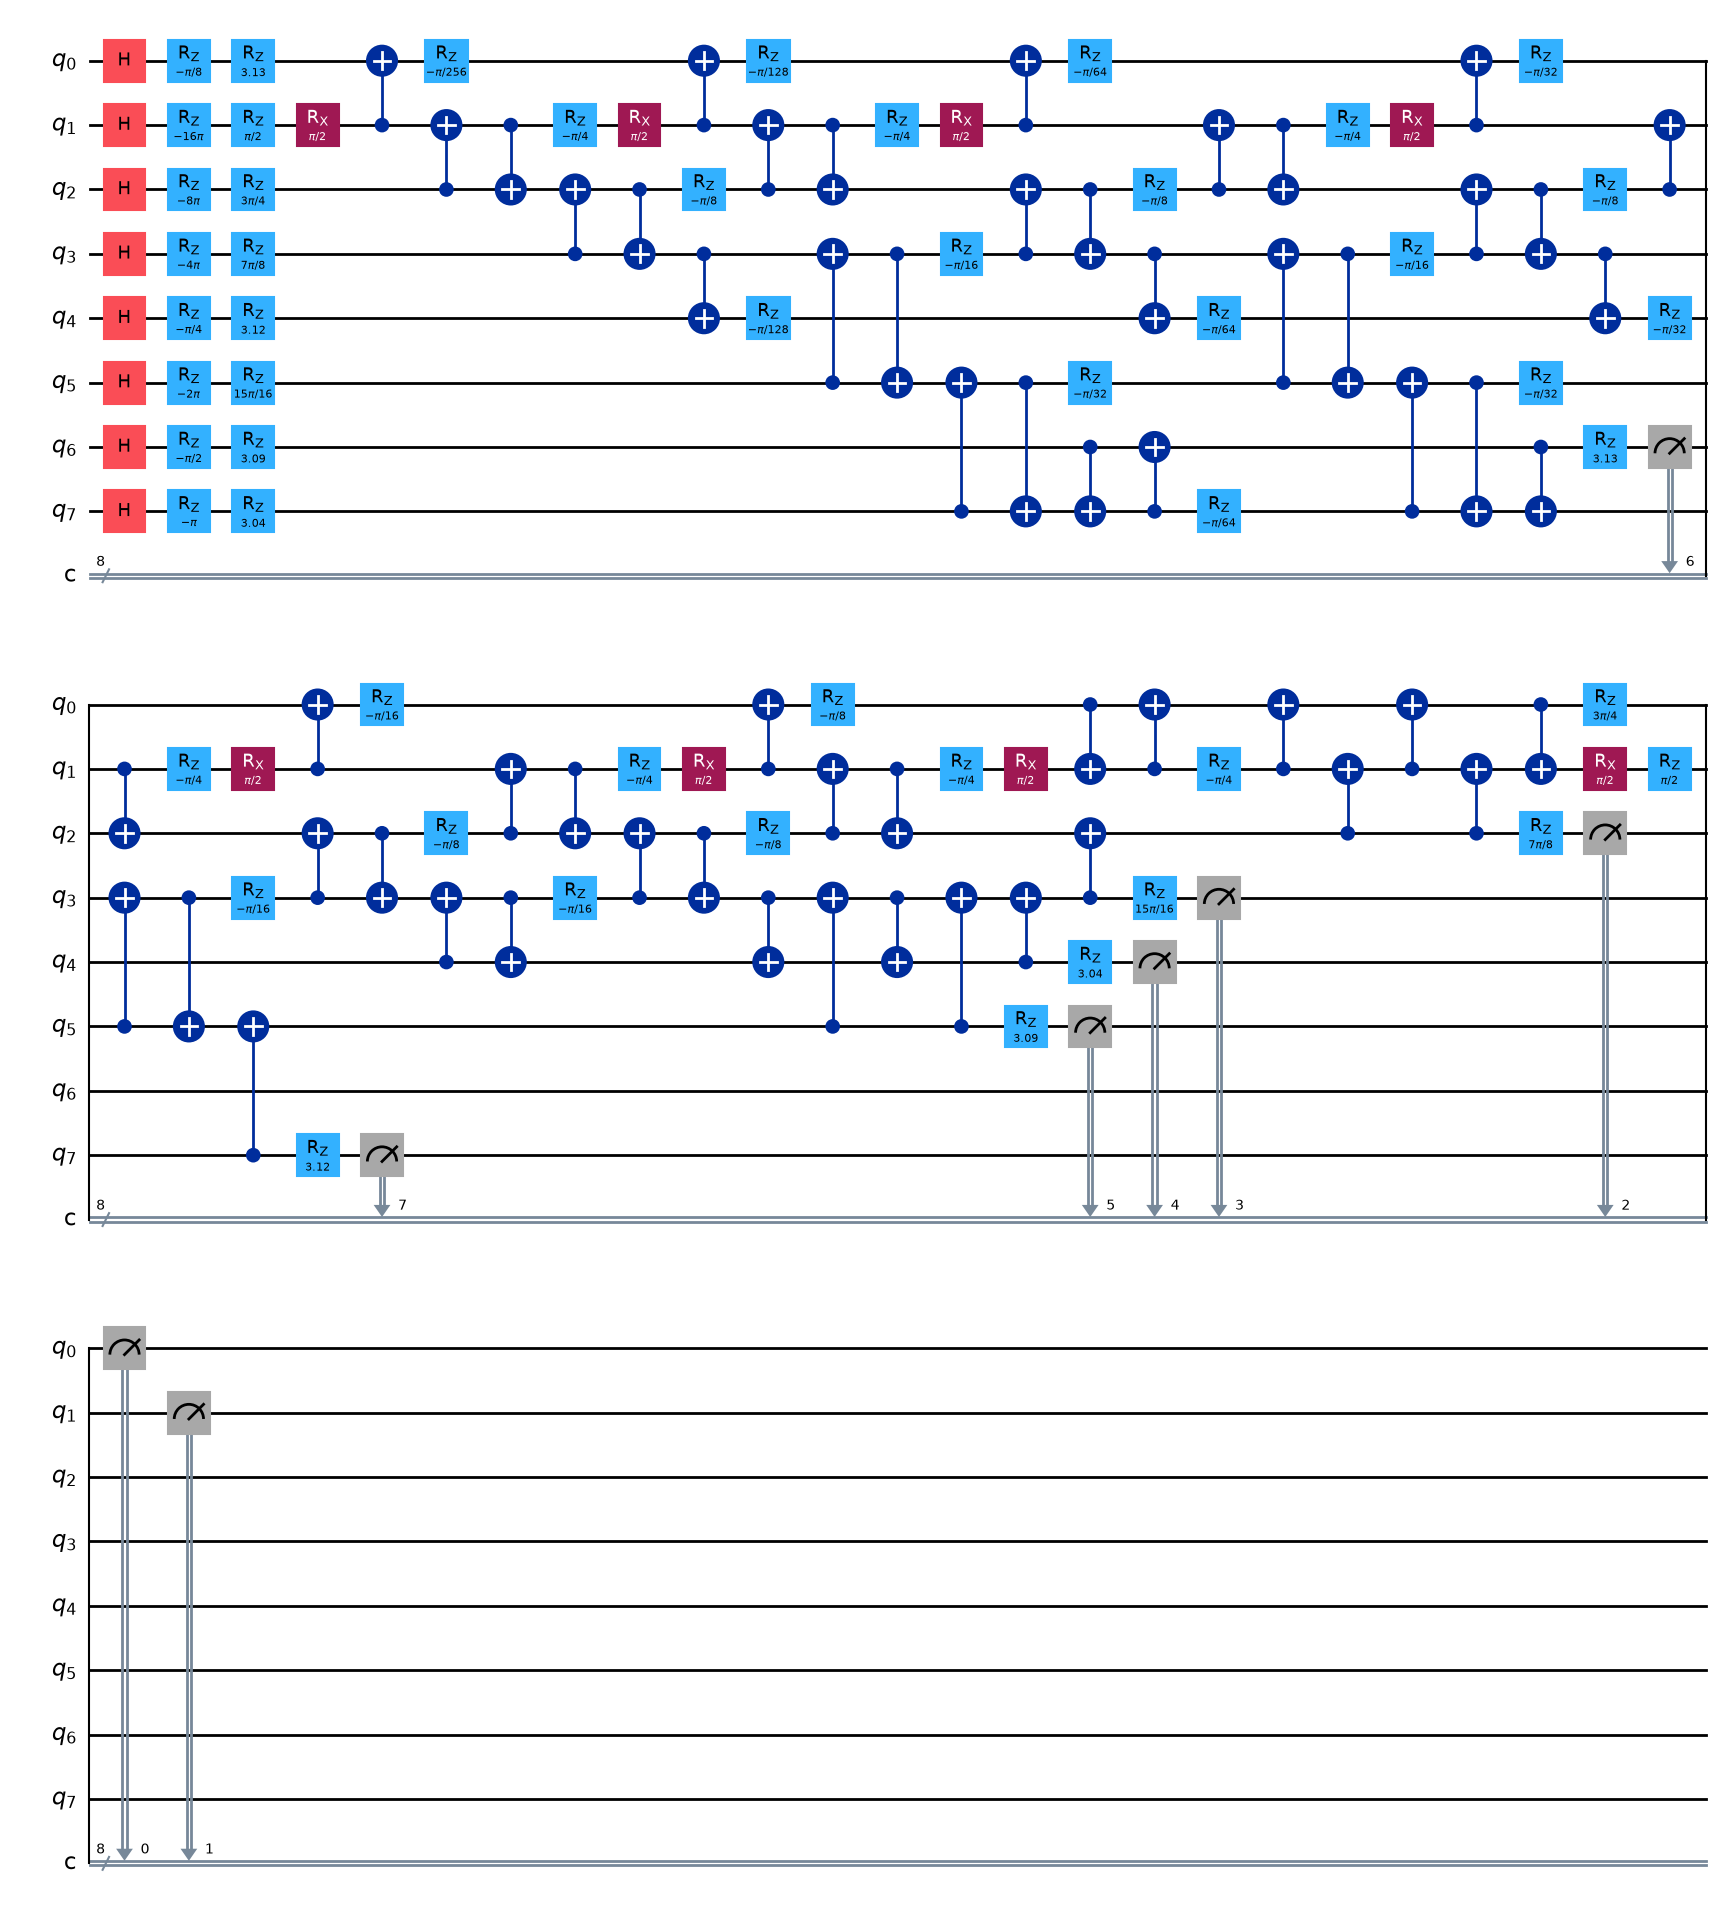

In [6]:
lc.plot_circuit(circuit_df, id_number=70, qft_method='TwineQFTHeavyHex')

In [7]:
# 1. Grab the OpenQASM string using your relative filtering method
# (e.g., Target the 0th circuit of the FowlerQFT method)
filtered_df = circuit_df[circuit_df['qft_method'] == 'FowlerQFT']
qasm_string = filtered_df.iloc[70]['transpiled_circuit']

# 2. Convert text string to Qiskit Circuit object
circuit_obj = loads(qasm_string)

# 3. Analyse the circuit
circuit_metrics = lc.analyse_circuit_parameters(circuit_obj)

pprint.pprint(circuit_metrics)

{'circuit_depth': 70,
 'gate_breakdown': {'cx': 84, 'h': 16, 'measure': 8, 'rz': 92},
 'num_clbits': 8,
 'num_qubits': 8,
 'one_qubit_gate_count': 116,
 'total_gate_count': 200,
 'two_qubit_gate_count': 84}


## Loading The Fidelity Results 

Update with correct relative path for each dataset

In [ ]:
with open('.../parity_qc_data/qctrltwineqftheavyhex_data.csv') as f:
    reader = csv.reader(f)
    columns_as_lists = [list(c) for c in zip(*reader)]

fidelity_heavyhex_fo = columns_as_lists[1][1:]
no_qubits_heavyhex_fo = columns_as_lists[0][1:]

print(len(fidelity_heavyhex_fo))

580


In [ ]:
with open('.../parity_qc_data/qctrltwineqftlinear_data.csv') as f: 
    reader = csv.reader(f)
    columns_as_lists = [list(c) for c in zip(*reader)]

fidelity_linear_fo = columns_as_lists[1][1:]
no_qubits_linear_fo = columns_as_lists[0][1:]

print(len(fidelity_linear_fo))

580


In [ ]:
with open('.../parity_qc_data/qctrlfowlerqft_data.csv') as f: 
    reader = csv.reader(f)
    columns_as_lists = [list(c) for c in zip(*reader)]  

fidelity_fowler_fo = columns_as_lists[1][1:]
no_qubits_fowler_fo = columns_as_lists[0][1:]

print(len(fidelity_fowler_fo))

580


In [12]:
#function to store circuit metrics in a dictionary indexed by circuit ID, qft method, fidelity, and number of qubits

def store_circuits_in_dict(
    circuit_ids: list, qft_types: list, fidelities: list, n_qubits: list
) -> dict:
    """Combines circuit metrics into a structured dictionary indexed by Circuit

    ID.
    """
    circuit_dict = {}

    # zip handles the parallel list parsing
    for cid, qft, fid, nq in zip(circuit_ids, qft_types, fidelities, n_qubits):
        # We save the data as a nested dictionary under the circuit ID key
        circuit_dict[cid] = {"qft_type": qft, "fidelity": fid, "n_qubits": nq}

    return circuit_dict


In [13]:
#loop over like this to store into separate dictionaries for each circuit ID, qft method, fidelity, and number of qubits
for i in range(21):
    print(store_circuits_in_dict(circuit_ids= [i], qft_types = ['TwineQFTHeavyHex'], fidelities = [float(fidelity_heavyhex_fo[i])], n_qubits= [int(no_qubits_heavyhex_fo[i])]))

{0: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9888909360293584, 'n_qubits': 2}}
{1: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9890125944356748, 'n_qubits': 2}}
{2: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.987865879075383, 'n_qubits': 2}}
{3: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9885094559868202, 'n_qubits': 2}}
{4: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9896022468266412, 'n_qubits': 2}}
{5: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.988597353203474, 'n_qubits': 2}}
{6: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9895850319670914, 'n_qubits': 2}}
{7: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9893835294334672, 'n_qubits': 2}}
{8: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9885335504824724, 'n_qubits': 2}}
{9: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9880369129394364, 'n_qubits': 2}}
{10: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9894412586500306, 'n_qubits': 2}}
{11: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.98836943732687

In [14]:
#alternatively, you can store all the circuit metrics in a single dictionary by passing lists of all the circuit IDs, qft methods, fidelities, and number of qubits to the function
#but remember to update for whatever range of circuit IDs you want to store in the dictionary (e.g., 0-20 for the first 21 circuits)
print(store_circuits_in_dict(circuit_ids= [i for i in range(21)], 
                             qft_types = ['TwineQFTHeavyHex'] * 21, 
                             fidelities = [float(fidelity_heavyhex_fo[i]) for i in range(21)], 
                             n_qubits= [int(no_qubits_heavyhex_fo[i]) for i in range(21)]))

{0: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9888909360293584, 'n_qubits': 2}, 1: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9890125944356748, 'n_qubits': 2}, 2: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.987865879075383, 'n_qubits': 2}, 3: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9885094559868202, 'n_qubits': 2}, 4: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9896022468266412, 'n_qubits': 2}, 5: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.988597353203474, 'n_qubits': 2}, 6: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9895850319670914, 'n_qubits': 2}, 7: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9893835294334672, 'n_qubits': 2}, 8: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9885335504824724, 'n_qubits': 2}, 9: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9880369129394364, 'n_qubits': 2}, 10: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9894412586500306, 'n_qubits': 2}, 11: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9883694373268712, 'n_qubi